   ...

   For $n$ bits, the range is -2^(n-1) to 2^(n-1)-1...

   SIGN EXTENSION means copying the MSB when you widen a number. `1011` (-5 in
   4 bits) becomes `11110111` (still -5 in 7 bits). The new bits are all copies
   of the sign bit. This is why the I-type immediate in RISC-V gets 
   "sign-extended" from 12 bits to 32/64 bits -- it preserves the value whether
   positive or negative. 

   OVERFLOW ... The rules... if you add two +ve and get a -ve, or add two -ve,
   and get a +ve, something went wrong... The ALU needs to detect this.


---
2. LOGICAL OPERATIONS   
   Before building the ALU, the lecture catalogs what it needs to support.
                                            <-- `slii` (Shift Left Logical Immediate)
   SHIFTS move all bits left or right by some amount. `slli x10, x16, 8` shifts
   x16 left by 8 bits, filling the empty positions with zeros. Left shift by
   $n$ is equivalent to multiplying by 2^n ... Right shift by n divides by 2^n.

   There's a subtlety with right shifts: `srl` (shift right logical) fills the 
   top with zeros, while `sra` (shift right arithmetic) copies the sign bit. 
   This matters for negative numbers -- `sra` preserves the sign, so 
   -8 >>> 1 = -4 (correct division by 2), while logical right shift would give a
   large +ve number.

   BITWISE OPERATION (`and`, `or`) operate on each pair of corresponding bits
   independently. These are important for masking (isolating specific bits),
   setting flags, and clearing bits -- you used `band` extensively in your
   FunnyCore division code.



---
3. BUILDING BLOCKS: THE GROUND FLOOR
   The ALU needs to compute AND, OR, ADD, and SUB. The lecture builds it from
   the smallest pieces upward.

   INVERTER: flips 0->1 and 1-> 0. Symbol is a triangle with a circle.
   MULTIPLEXER (MUX): a switch. Two inputs (a, b), one control (d), one output.
      If d=0, output=a. If d=1, output=b. You're already familiar with these...
   HIGH-LEVEL ALU STRUCTURE: Two n-bit inputs A and B feed into three parallel
      blocks -- AND gates, OR gates, and an adder. A mux at the output selects
      which result to use. The B input passes through a programmable inverter
      first (for subtraction).      








---

   ... let's rewind to the fundamentals and build up from scratch with real 
   numbers. Carry-out has nothing to do with C++ `cout`... Let's start from the
   very beginning.


WHAT IS A CARRY?
   Think about how you do addition by hand in decimal. If you add 7 + 5, you get
   12 -- you write down the 2 and CARRY THE 1 to the next column. Binary
   addition works exactly the same way, just with 0s and 1s. 

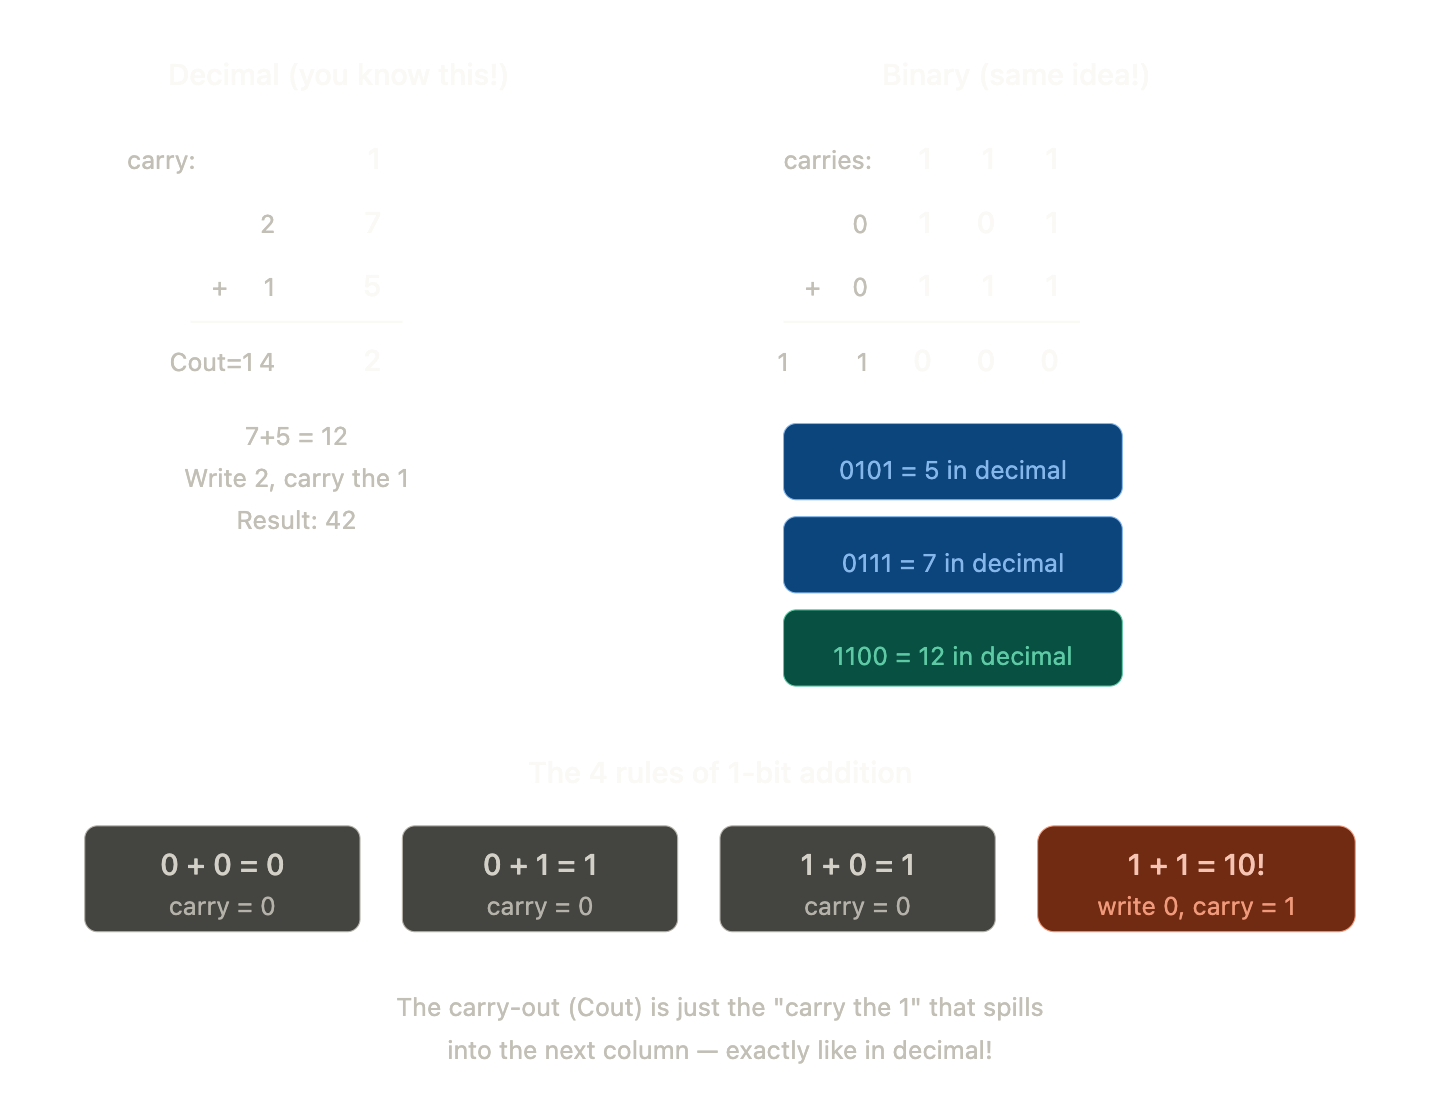

   So CARRY-OUT is just the "carry the 1" from primary school maths, but in
   binary. When 1+1=10 in binary, the 0 stays in the current column and the 1
   gets carried out to the next column. That carried bit is the "carry-out".
   Nothing to do with...

   Now let's ... MUX--this one's actually really intuitive once you see it.


---
WHAT IS A MUX (multiplexor)?
   Think of a MUX as a SWITCH or TV channel selector. Multiple signals come in,
   but only ONE goes through to the output. A control signal decides which one.

   

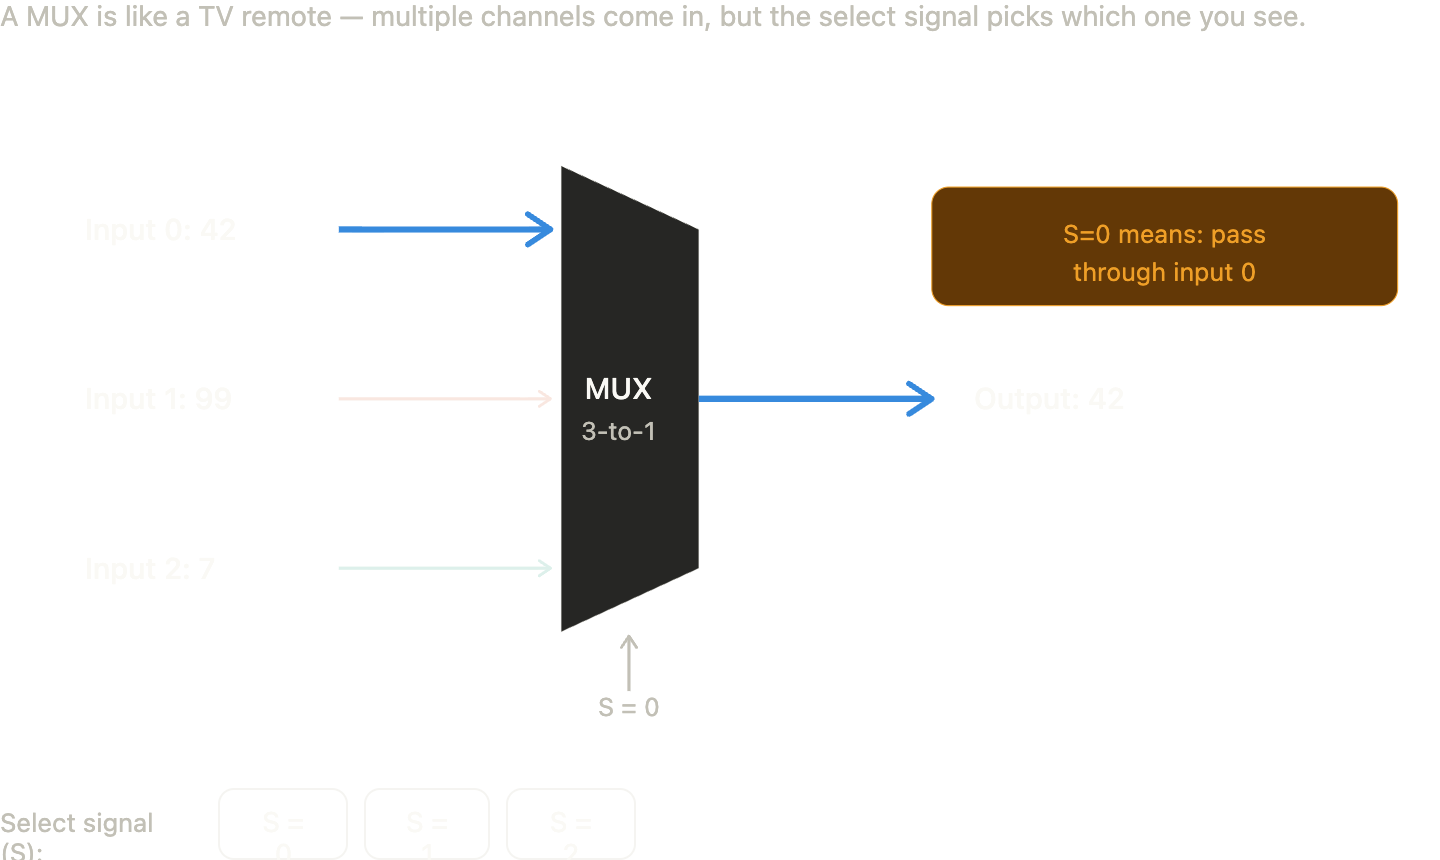

   ... clicking the different $S$ values above -- you'll see how only the
   selected input "passes through" to the output. That's all a MUX is: a
   selector switch controlled by a signal.

   Now that you understand both carry and MUX, let me show you the actual 
   add-subtract circuit from your lecture slide, with REAL NUMBERS FLOWING 
   THROUGH IT so you can see exactly what happens.


### THE ADD-SUBTRACT CIRCUIT IN ACTION   

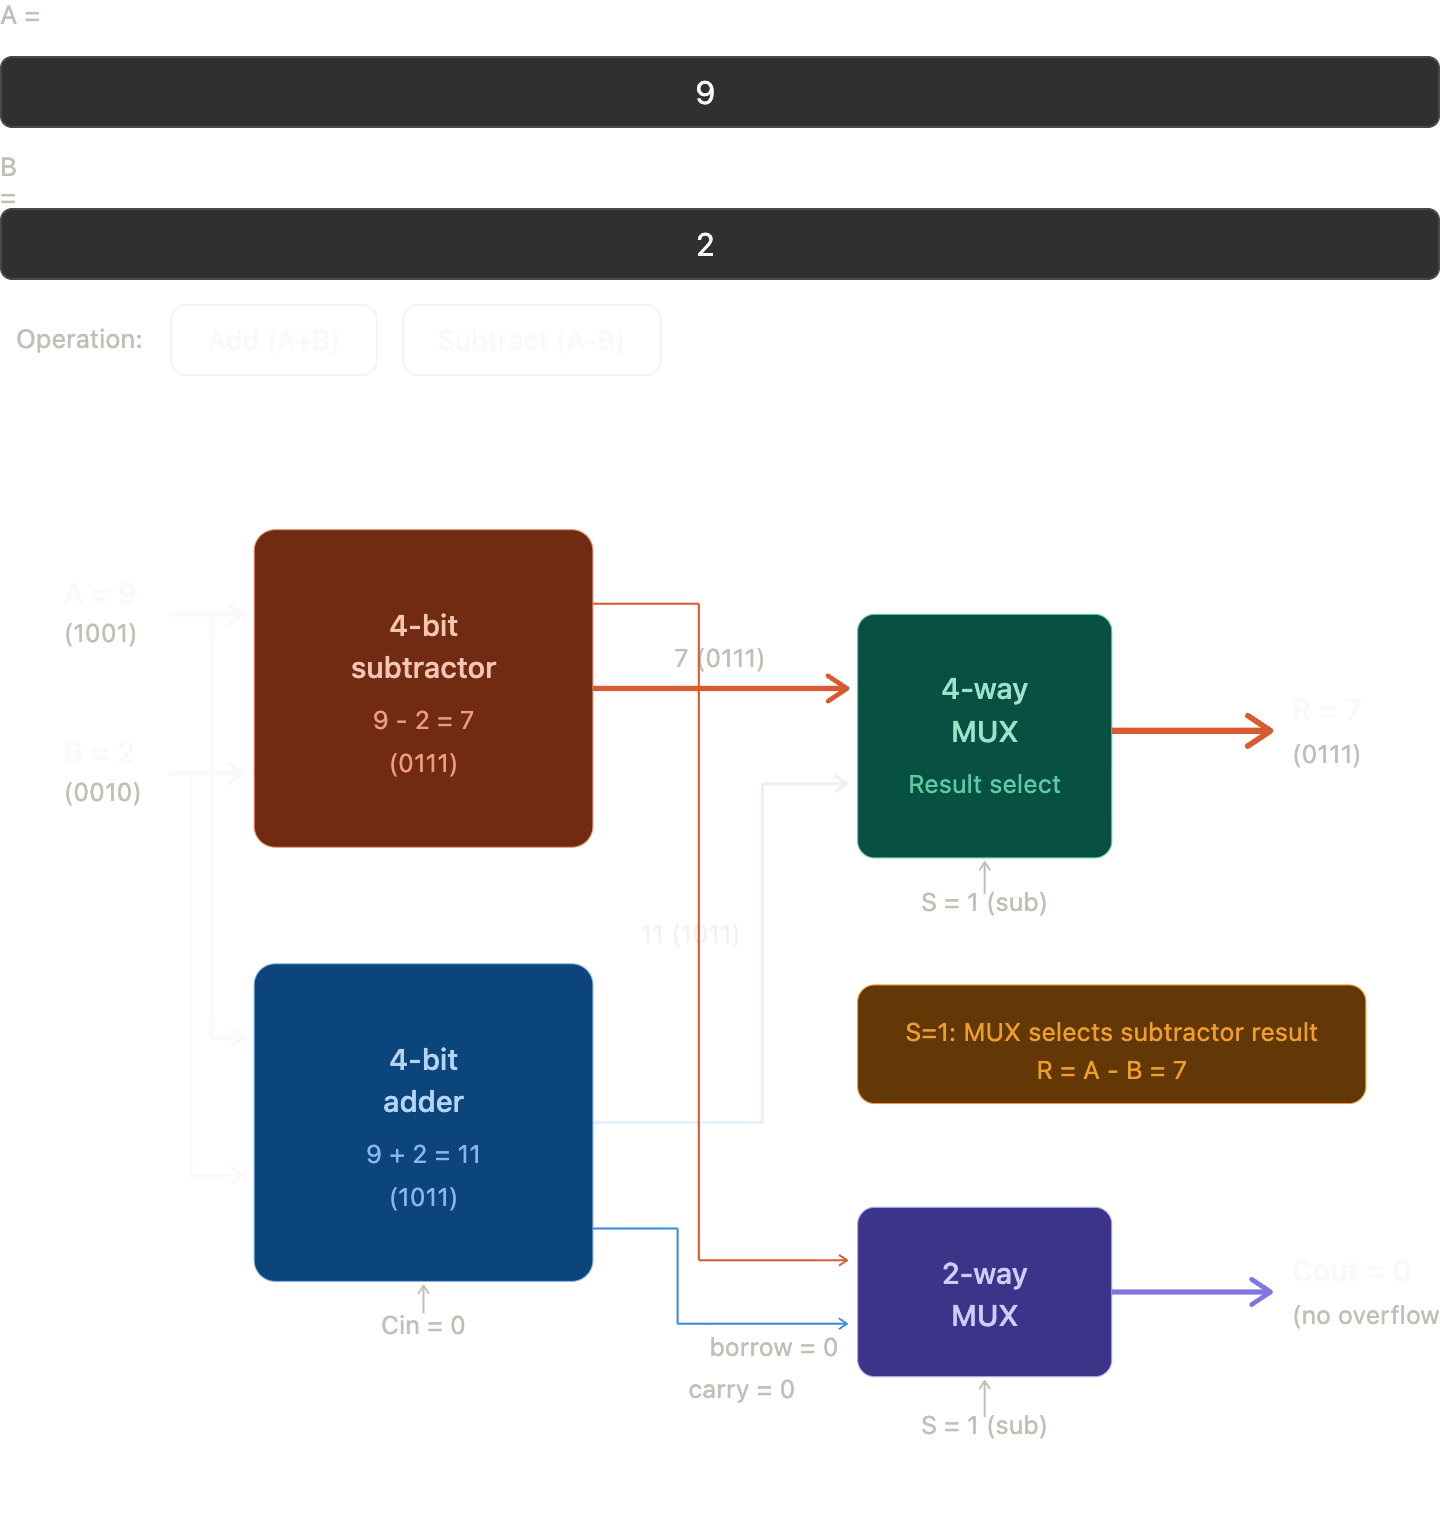

   Play around with the values of A and B above, ... and toggle between Add and
   Subtract to see the data flow change. Try setting A=3, B=12 with Subtract to
   see what happens when the result goes negative (the borrow flag lights up).
   Or try ... to see the carry overflow.

   ... tie this all together ...:

   THE WHOLE CIRCUIT DOES THIS: Both the adder and subtractor receive the same A
   and B inputs and compute their results at the same time -- they're always
   running in parallel. The actual outputs of the circuit are decided by two
   MUXes.

   MUX 1 (result select) looks at both the adder's 4-bit answer and the 
   subtractor's 4-bit answer, and based on the select signal S, passes one of
   them through as R. If you asked for addition, it picks the adder's answer.
   ...

   MUX 2 (Cout select) does the same thing but for the "extra bit" -- the carry
   from the adder or the borrow from the subtractor. This tells you whether the
   result overflowed (was too big for 4 bits to hold, or went negative).

   The beauty is that S is the only control signal you need. One wire decides
   the entire operation. And as your lecture goes on to show, this idea extends 
   to the full ALU where the MUX has even more inputs (AND, OR results too) and
   a 2-bit select signal picks from all four operations.






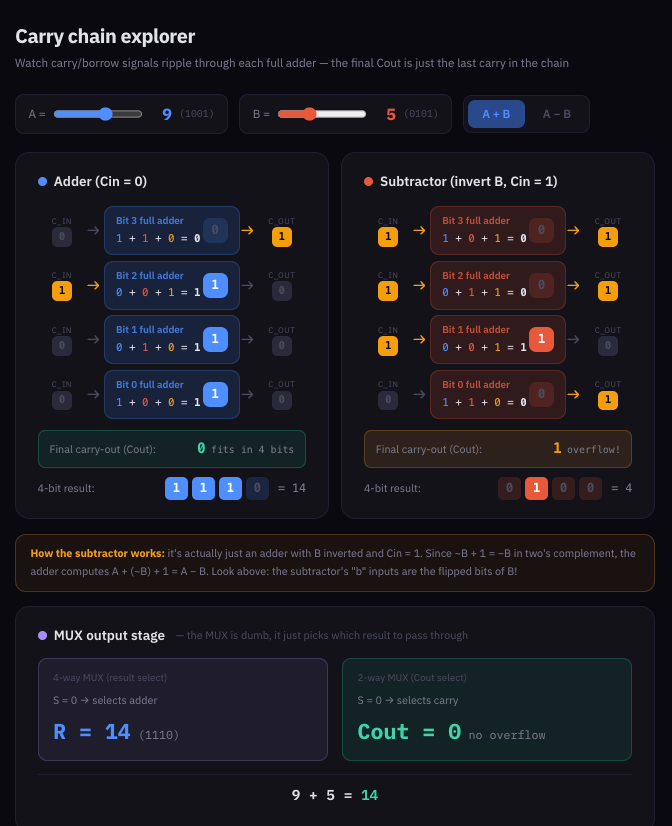

   ... HOW THE SUBTRACTOR WORKS: it's actually just an adder with B inverted
   and Cin = 1. Since -B + 1 = -B in two's complement. the adder computes
   A + (-B) + 1 = A - B. Look above: the subtractor's "b" inputs are the flipped
   bits of B!

   Great question -- the MUX is "dumb", it doesn't figure anything out. The
   adder and subtractor NATURALLY PRODUCE carry/borrow as a byproduct of the
   maths itself. Let me show...

   Think back to the primary school addition. When you add 7+5 in a column, you
   don't have a separate "overflow detector" -- the carry just happens because
   the result doesn't fit in one digit. Same thing in hardware: the carry-out
   literally falls out of the addition logic for free.

   ...


---

   Play around with the sliders and togle between...

   A=15, B=1, ADD -- watch the carry ripple all the way from bit 0 through to 
   the final Cout. This is like 1111+0001 = 10000, and the leading 1 doesn't
   fit in 4 bits, so Cout = 1.

   A=3, B=7, SUBTRACT -- the result is negative (-4), so the borrow flag fires.
   Look at how the subtractor panel inverts B's bits (7 = 0111 becomes 1000) and
   sets Cin = 1.

   A=8, B=8, ADD -- another clean overflow case.

   To directly answer your question: the adder DOESN'T HAVE A SPECIAL OVERFLOW
   DETECTOR. The carry-out is jut the natural consequence of the last full
   adder in the chain having nowhere to send its carry. Each full adder takes
   three single-bit inputs (a, b, carry-in from the previous bit) and produces
   a sum bit and a carry-out bit. That carry-out feeds into the next full 
   adder's carry-in. The very last full-adder (bit 0, the MSB) has no "next
   bit" to send its carry to -- so that carry just exits the circuit as Cout.
   It's not detected, it's produced -- it falls out of the maths for free.

   The 2-way MUX at the bottom does absolutely nothing clever. It just asks:
   "are we adding or subtracting?" If adding, pass through the adder's final
   carry. if subtracting, pass through the ... pure routing, zero logic.

---

   In single-bit mode, try these to build your intuition:

   Hit the "ADD (1+1)" preset first. You'll see: a=1 and b=1 enter the slice, 
   they pass through the Binv MUX unchanged (since Binv=0), then all three gates
   (AND, OR, full adder) compute in parallel. The output MUX picks the adder's
   result: 1+1=0 = sum bit 0, cout 1. That cout is the carry that would ripple
   into the next bit.

   Now hit "SUB (1-1)" -- this is where the magic happens. Watch how Binv flips
   b from 1 to 0, then the adder computes `a + NOT(b) + Cin = 1 + 0 + 1 = sum bit 0, cout 1`
   The result is 0 -- correct! There's no separate subtractor hardware, just a 
   flipped input and an extra +1 via Cin.

   Then hit "SUB (0-1)" to see a negative result. The adder computes ... 
   `... = sum bit 1, cout 0`. In a single bit this is tricky, but in the 4-bit
   view you'll see the full picture.


IN 4-BIT MODE, TRY:
   Set A=9, B=5, SUBTRACT -- you'll see all 4 slices chained together. Each 
   bit's cout feeds into the next bin's cin (highlighted in amber). Binv is 1
   everywhere, and bit 0 gets Cin=1 -- that's the two's complement trick giving
   you 9-5=4 without any subtractor.

   Set A=15, B=1, ADD -- watch the carry ripple all the way from bit 0 to the
   final Cout (the carry "waterfall" effect).

   Set A=6, B=3, AND -- notice how the carry chain still runs but gets 
   completely ignored -- the output MUX just picks the AND result from each 
   slice. The adder is doing work for nothing, but that's the trade-off for
   keeping the hardware simple and uniform. 

   The key takeaway: ONE piece of adder harware handles both addition and 
   subtraction. The only difference is two control wires (Binv and Cin). That's
   the entire trick your lecture is building toward!


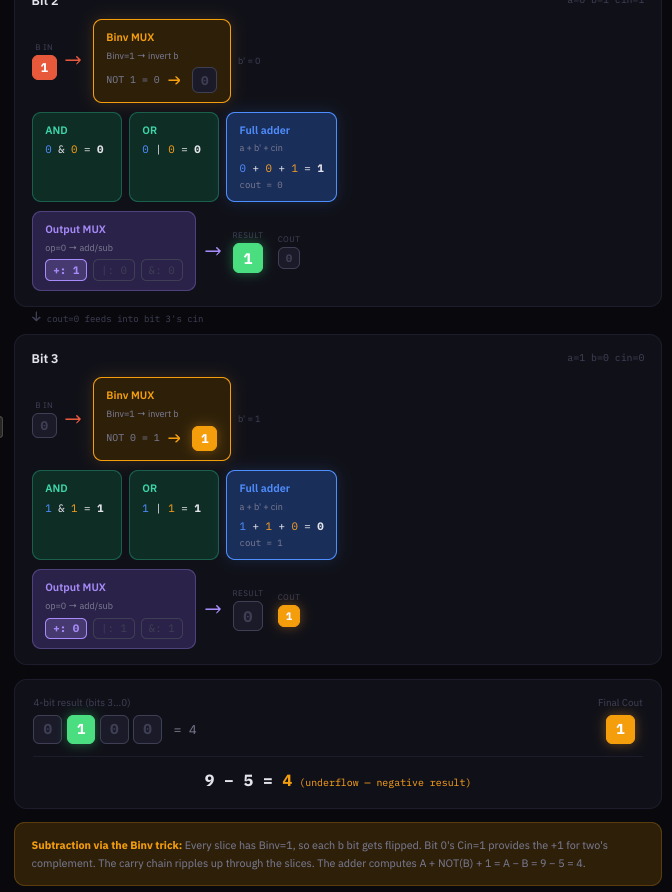

   ...

   One key step is to ensure the interfaces -- the ordering of the list of
   inputs or outputs -- of a block and its bit-level realisation are exactly the
   same. Hence we MAKE EXPLICIT THE INTERLEAVE OF WIRING (inside the red dotted
   box) connecting the corresponding inputs to a particular gate.



---
   Similarly, the wires connecting the two inputs to an adder block would need
   to be interleaved, such that the corresponding bits would be connected to the
   inputs of a full adder `fa` in a ripple carry adder. Subtraction can be 
   computed by inverting the second input and by initialising the carry-in of 
   the LSB full adder to a constant one.






